✅ Laddat 1000 kunder/konton och 88245 transaktioner.

📂 Kolumner i customers_accounts_clean:
['Customer', 'Address', 'Phone', 'Personnummer', 'BankAccount']

📂 Kolumner i transactions_clean:
['transaction_id', 'timestamp', 'amount', 'currency', 'sender_account', 'receiver_account', 'sender_country', 'sender_municipality', 'receiver_country', 'receiver_municipality', 'transaction_type', 'notes']


,Customer,Address,Phone,Personnummer,BankAccount
0,Sofie Ibrahim,"Ängsvägen 03, 14010 Gävle",061-608 60 88,400118-5901,SE8902EPWK73250364544965
1,Sofie Ibrahim,"Ängsvägen 03, 14010 Gävle",061-608 60 88,400118-5901,SE8902IDSK51225196610969
2,Mona Lundgren,"Kyrkvägen 084, 49722 Göteborg",+46 (0)396 101 64,391117-9285,SE8902OGIV86383792142837
3,Mona Lundgren,"Kyrkvägen 084, 49722 Göteborg",+46 (0)396 101 64,391117-9285,SE8902QZEZ52320024971424
4,Tuulikki Blomqvist,"Kvarnvägen 654, 94181 Borås",+46 (0)918 939 10,981215-7254,SE8902DWZI85436013187521


,transaction_id,timestamp,amount,currency,sender_account,receiver_account,sender_country,sender_municipality,receiver_country,receiver_municipality,transaction_type,notes
0,62cacc89-95ca-41c0-a06f-d12950c85a37,2025-01-08 03:17:00,1174.47,SEK,SE8902ZCTK81497780781136,SE8902GGWE97497502378359,Sweden,Södertälje,Sweden,Stockholm,outgoing,Tax refund
1,d1ae6818-9d0f-4e14-bc56-0165e8123ff0,2025-01-02 19:34:00,19068.02,SEK,SE8902DGXX88147139459340,SE8902PLBL16144667744762,Sweden,Uddevalla,Sweden,Karlskoga,incoming,Salary payment
2,aa707bbc-7171-4a8f-bdd1-5a18943708d5,2025-01-12 20:08:00,7557.86,SEK,SE8902VMWP60739361675669,SE8902JTIU30473679174736,Sweden,Gävle,Sweden,Nyköping,outgoing,Subscription fee
3,40adfe97-ed7c-483e-bd50-cdec4726fc80,2025-02-08 06:24:00,14108.32,SEK,SE8902GHSB29020078073922,SE8902MQTA07583386361028,Sweden,Trelleborg,Sweden,Gävle,outgoing,Payment for invoice #1934
4,92755c2b-332c-4f8d-960d-82f0399b4ea4,2025-02-03 09:56:00,5271.49,SEK,SE8902PVNM34258841032637,SE8902OFTJ79383582820961,Sweden,Borlänge,Sweden,Lidingö,incoming,Rent transfer


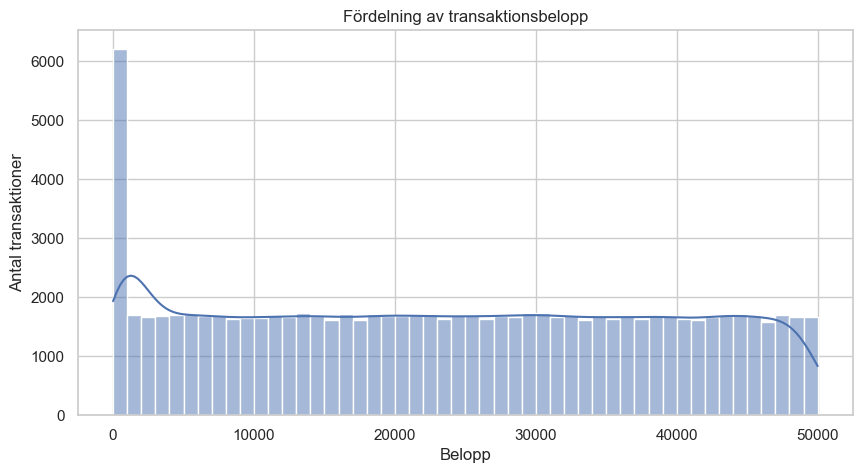

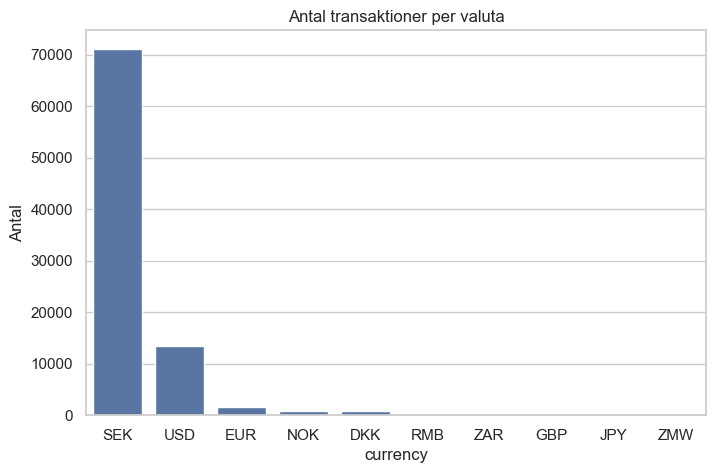

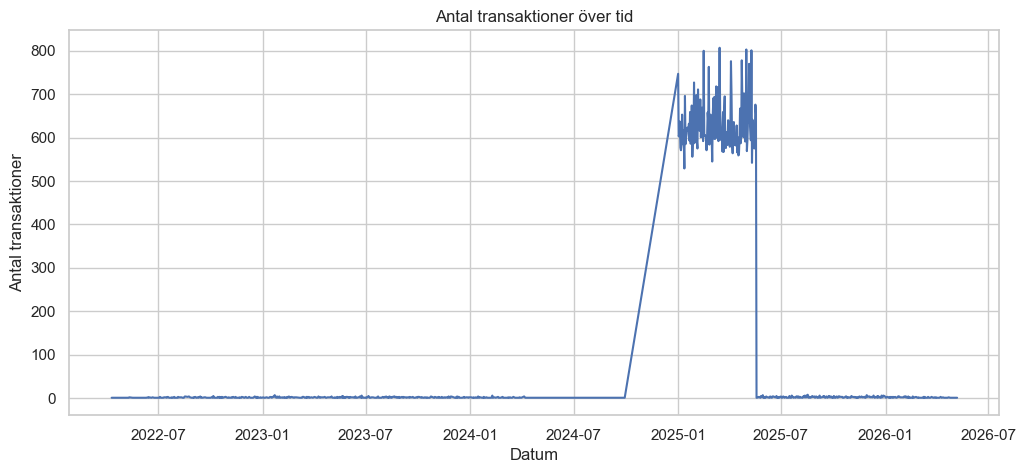

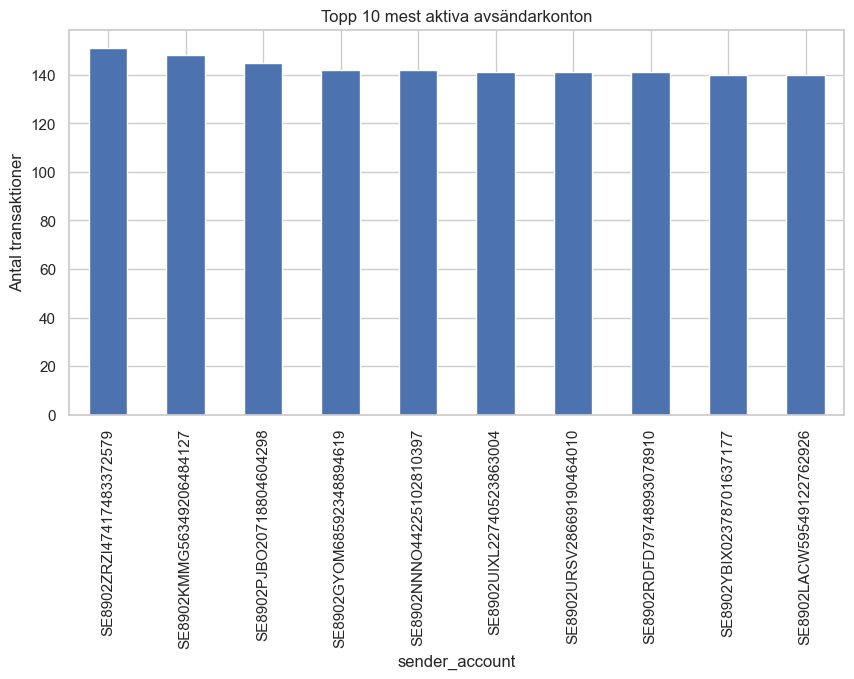

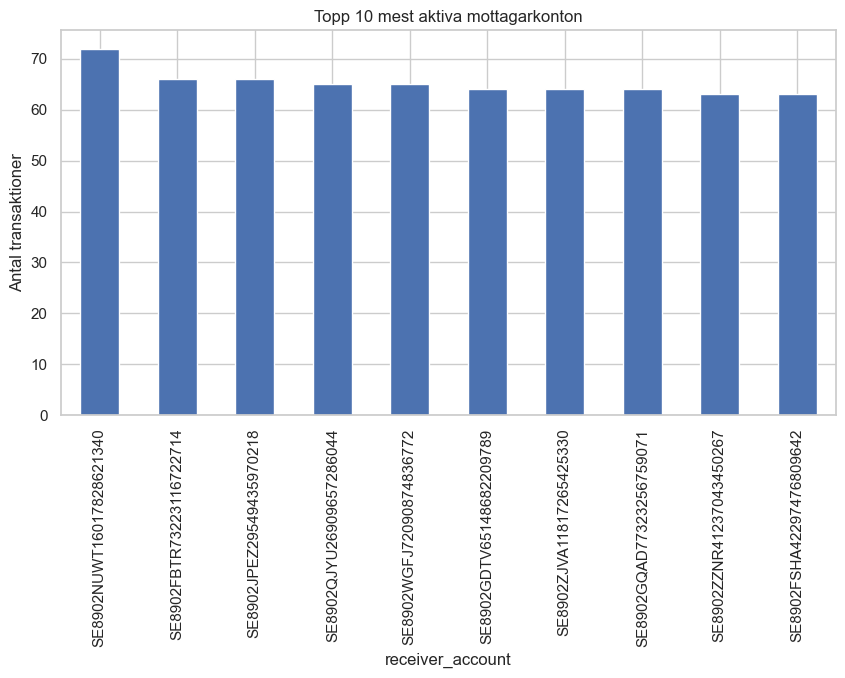


⚠️ Antal misstänkta transaktioner (>100000): 0


,transaction_id,timestamp,amount,currency,sender_account,receiver_account,sender_country,sender_municipality,receiver_country,receiver_municipality,transaction_type,notes


✅ Analys klar! Diagram har genererats.


In [ ]:
### Analysfil för bankdata

# --- 1. Importer ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ställ in standardstil för diagram
sns.set(style="whitegrid")

# --- 2. Läs in cleanade CSV-filer ---
customers = pd.read_csv("../data/clean/customers_accounts_clean.csv")
transactions = pd.read_csv("../data/clean/transactions_clean.csv")

print(f"✅ Laddat {len(customers)} kunder/konton och {len(transactions)} transaktioner.")

# --- 3. Översikt av data ---
print("\n📂 Kolumner i customers_accounts_clean:")
print(customers.columns.tolist())
print("\n📂 Kolumner i transactions_clean:")
print(transactions.columns.tolist())

display(customers.head())
display(transactions.head())

# --- 4. Analys & Grafer ---

## 4.1 Fördelning av transaktionsbelopp
plt.figure(figsize=(10,5))
sns.histplot(transactions['amount'], bins=50, kde=True)
plt.title("Fördelning av transaktionsbelopp")
plt.xlabel("Belopp")
plt.ylabel("Antal transaktioner")
plt.show()

## 4.2 Transaktioner per valuta
plt.figure(figsize=(8,5))
sns.countplot(data=transactions, x="currency", order=transactions["currency"].value_counts().index)
plt.title("Antal transaktioner per valuta")
plt.ylabel("Antal")
plt.show()

## 4.3 Transaktioner över tid
if "timestamp" in transactions.columns:
    transactions["timestamp"] = pd.to_datetime(transactions["timestamp"], errors='coerce')
    transactions_by_date = transactions.groupby(transactions["timestamp"].dt.date).size()
    plt.figure(figsize=(12,5))
    transactions_by_date.plot()
    plt.title("Antal transaktioner över tid")
    plt.ylabel("Antal transaktioner")
    plt.xlabel("Datum")
    plt.show()

## 4.4 Topp 10 avsändarkonton
top_senders = transactions["sender_account"].value_counts().head(10)
plt.figure(figsize=(10,5))
top_senders.plot(kind="bar")
plt.title("Topp 10 mest aktiva avsändarkonton")
plt.ylabel("Antal transaktioner")
plt.show()

## 4.5 Topp 10 mottagarkonton
top_receivers = transactions["receiver_account"].value_counts().head(10)
plt.figure(figsize=(10,5))
top_receivers.plot(kind="bar")
plt.title("Topp 10 mest aktiva mottagarkonton")
plt.ylabel("Antal transaktioner")
plt.show()

# --- 5. Misstänkta transaktioner ---
threshold = 100000
suspicious_tx = transactions[transactions["amount"] > threshold]

print(f"\n⚠️ Antal misstänkta transaktioner (>{threshold}): {len(suspicious_tx)}")
display(suspicious_tx.head())

if not suspicious_tx.empty:
    plt.figure(figsize=(10,5))
    sns.histplot(suspicious_tx["amount"], bins=20, kde=True, color="red")
    plt.title(f"Fördelning av misstänkta transaktioner (> {threshold})")
    plt.xlabel("Belopp")
    plt.ylabel("Antal transaktioner")
    plt.show()

print("✅ Analys klar! Diagram har genererats.")

In [37]:
# Koppla ihop transactions med customers_accounts för att få kundinfo för avsändare
merged_sender = transactions.merge(
    customers_accounts,
    left_on="sender_account",   # i transactions
    right_on="BankAccount",     # i customers_accounts
    suffixes=("", "_sender")
)

# Koppla ihop igen för mottagare
merged_full = merged_sender.merge(
    customers_accounts,
    left_on="receiver_account",
    right_on="BankAccount",
    suffixes=("", "_receiver")
)

print(merged_full.columns)


Index(['transaction_id', 'timestamp', 'amount', 'currency', 'sender_account',
       'receiver_account', 'sender_country', 'sender_municipality',
       'receiver_country', 'receiver_municipality', 'transaction_type',
       'notes', 'Customer', 'Address', 'Phone', 'Personnummer', 'BankAccount',
       'Customer_receiver', 'Address_receiver', 'Phone_receiver',
       'Personnummer_receiver', 'BankAccount_receiver'],
      dtype='object')


Tabeller i databasen: []
